In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split # Tạm dùng để tách validation/test
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [5]:
CSV_FILE = "/home/haopd/stock/data/GOOGL_1year.csv" # File CSV đã tạo từ bước trước
FEATURES = ['Open', 'High', 'Low', 'Close', 'Volume'] # Các đặc trưng sử dụng
TARGET = 'Target'
SEQUENCE_LENGTH = 6 # Sử dụng dữ liệu 6 tháng trước để dự đoán
BATCH_SIZE = 16 # Kích thước lô
HIDDEN_SIZE = 64 # Số units trong lớp LSTM
NUM_LAYERS = 2    # Số lớp LSTM chồng lên nhau
LEARNING_RATE = 0.001
EPOCHS = 100
TEST_SIZE = 0.15 # Tỷ lệ dữ liệu cho tập test
VALID_SIZE = 0.15 # Tỷ lệ dữ liệu (của phần còn lại sau test) cho tập validation
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
df_all = pd.read_csv(CSV_FILE, parse_dates=['Date'])
df_all.sort_values(by=['Date'], inplace=True)
df_all.head()

,Date,Close,High,Low,Open,Volume,Target
0,2006-09-01,10.009702,10.427872,9.382569,9.488917,4.857194e+09,1
1,2006-10-01,11.864945,12.252730,9.917300,10.009702,6.334219e+09,1
2,2006-11-01,12.074654,12.776753,11.582761,11.923973,4.732874e+09,0
3,2006-12-01,11.468693,12.263690,11.265958,12.103794,3.662901e+09,1
4,2007-01-01,12.490335,12.776754,11.484384,11.606174,4.978501e+09,0


In [15]:
data = df_all.filter(['Close'])
# Convert the dataframe to a numpy array
dataset = data.values
print(dataset.shape)
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

(224, 1)


213

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.0138087 ],
       [0.02325067],
       [0.02431795],
       [0.02123401],
       [0.0264335 ],
       [0.0198359 ],
       [0.02093993],
       [0.02261563],
       [0.02597844],
       [0.02912071],
       [0.02751091],
       [0.02817637],
       [0.03477017],
       [0.05248165],
       [0.05070708],
       [0.05051441],
       [0.03439372],
       [0.02259028],
       [0.01869764],
       [0.03566   ],
       [0.03711895],
       [0.02959223],
       [0.02291604],
       [0.02159019],
       [0.01363377],
       [0.00841654],
       [0.        ],
       [0.00186203],
       [0.00577624],
       [0.00570778],
       [0.0069842 ],
       [0.01305703],
       [0.01575185],
       [0.0163045 ],
       [0.01902466],
       [0.02138484],
       [0.02571733],
       [0.03082175],
       [0.03676403],
       [0.04145143],
       [0.03003841],
       [0.02964039],
       [0.03475116],
       [0.02950096],
       [0.0244219 ],
       [0.0192655 ],
       [0.02432302],
       [0.019

In [6]:
train_data = scaled_data[0:int(training_data_len), :]
test_data = scaled_data[training_data_len - SEQUENCE_LENGTH: , :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []
for i in range(SEQUENCE_LENGTH, len(train_data)):
    x_train.append(train_data[(i-SEQUENCE_LENGTH):i, 0])
    y_train.append(train_data[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

x_test = []
y_test = dataset[training_data_len:, :]
for i in range(SEQUENCE_LENGTH, len(test_data)):
    x_test.append(test_data[(i-SEQUENCE_LENGTH):i, 0])
   
# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))
print(x_train.shape)
print(x_test.shape)

(207, 6, 1)
(11, 6, 1)


In [11]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(x_train, y_train, batch_size=4, epochs=100)

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0357
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0018
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0022
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0019
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0032
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0019
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0021
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0018
Epoch 9/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0023
Epoch 10/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015
Epoch 11/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012
Epoch 12/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0021
Epoch 13/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015
Epoch 14/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013
Epoch 15/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0016
E

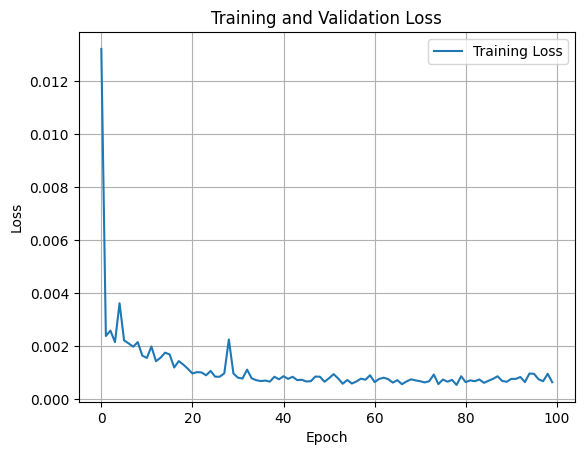

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
test_data = scaled_data[training_data_len - SEQUENCE_LENGTH: , :]
print(len(test_data))
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(SEQUENCE_LENGTH, len(test_data)):
    x_test.append(test_data[i-SEQUENCE_LENGTH:i, 0])
    
# Convert the data to a numpy array
x_test = np.array(x_test)
print(x_test.shape)
# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values 
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

17
[[0.67041399 0.6724907  0.66418386 0.72734602 0.78736787 0.83660087]
 [0.6724907  0.66418386 0.72734602 0.78736787 0.83660087 0.88547944]
 [0.66418386 0.72734602 0.78736787 0.83660087 0.88547944 0.83273548]
 [0.72734602 0.78736787 0.83660087 0.88547944 0.83273548 0.79135673]
 [0.78736787 0.83660087 0.88547944 0.83273548 0.79135673 0.80388192]
 [0.83660087 0.88547944 0.83273548 0.79135673 0.80388192 0.83170652]
 [0.88547944 0.83273548 0.79135673 0.80388192 0.83170652 0.82073867]
 [0.83273548 0.79135673 0.80388192 0.83170652 0.82073867 0.92406936]
 [0.79135673 0.80388192 0.83170652 0.82073867 0.92406936 1.        ]
 [0.80388192 0.83170652 0.82073867 0.92406936 1.         0.82848289]
 [0.83170652 0.82073867 0.92406936 1.         0.82848289 0.74897714]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


np.float64(23.484139900564518)

/tmp/ipykernel_299693/3344400724.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


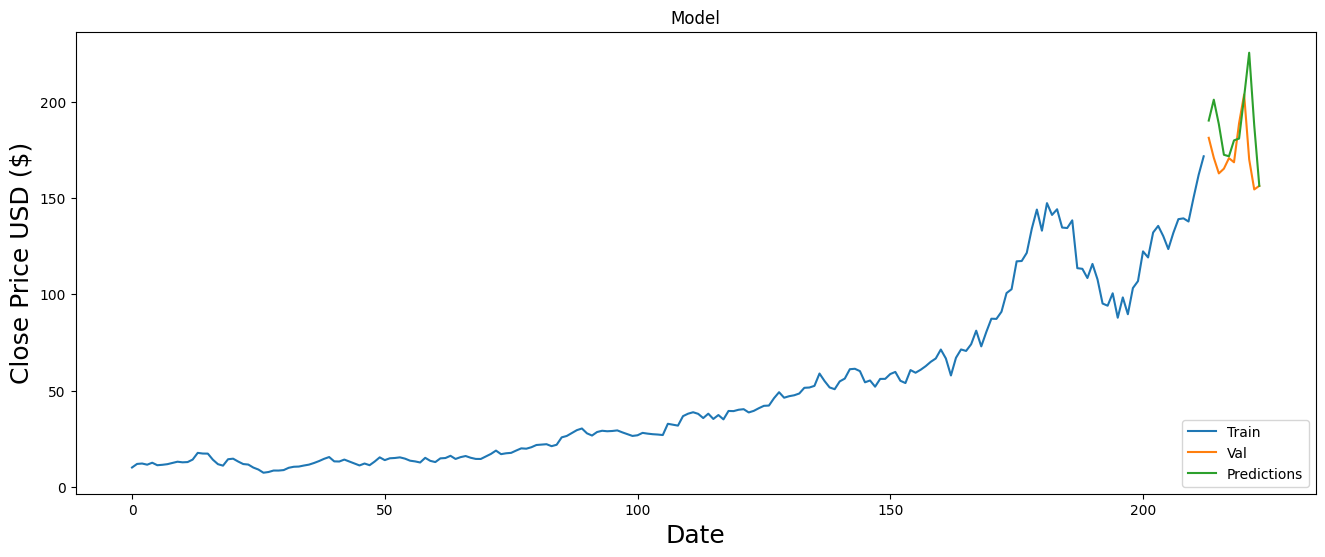

In [14]:
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [16]:
print(predictions)

[[190.23676]
 [201.08466]
 [188.34004]
 [172.4715 ]
 [171.68594]
 [179.95593]
 [180.88191]
 [202.53587]
 [225.48526]
 [187.72069]
 [156.33638]]


In [15]:
# Lưu lại model và scalar
import joblib

model.save("./models/model.h5")
joblib.dump(scaler, "models/scaler.save")

['models/scaler.save']

In [2]:
from tensorflow.keras.models import load_model
import joblib

scaler = joblib.load("./models/scaler.save")
# Load lại model
model = load_model("./models/model.h5")

# Kiểm tra kiến trúc
model.summary()

2025-04-16 02:17:22.890710: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-04-16 02:17:22.890745: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-04-16 02:17:22.890753: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: innovation-System-Product-Name
2025-04-16 02:17:22.890759: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:190] hostname: innovation-System-Product-Name
2025-04-16 02:17:22.890926: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:197] libcuda reported version is: 550.120.0
2025-04-16 02:17:22.890949: I external/local_xla/xla/stream_executor/cuda

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 6, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,621 (459.46 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [12]:
test_data = scaled_data[training_data_len - SEQUENCE_LENGTH: , :]
print(len(test_data))
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(SEQUENCE_LENGTH, len(test_data)):
    x_test.append(test_data[i-SEQUENCE_LENGTH:i, 0])
    
# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))
print(x_test.shape)
# Get the models predicted price values 
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

17
(11, 6, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


np.float64(23.484139900564518)